## 📌 Disclaimer

> **This project is for educational and entertainment purposes only.**  
>  
> The analyses, charts, and commentary provided herein are part of an academic data science project. They are **not intended as financial, investment, or trading advice**.  
>  
> Although real financial data is used, the information and models presented **do not guarantee accuracy, completeness, or future performance**.  
>  
> The author(s) of this project are **not licensed financial advisors**. Any investment-related observations are purely hypothetical and for illustrative purposes.  
>  
> **Please do not use this content as a basis for investment decisions.** Always seek advice from a qualified financial professional before making any financial decisions.


# 📊 Sector Rotation Analysis Using ETF Data (2020–2025)

## 1. 🎯 Objective of the Analysis
- Visualize **sector rotation** across economic cycles.
- Track sector performance using **sector ETFs**.
- Identify patterns in sector leadership around **key macro events** (e.g., Fed decisions, inflation).
- Support portfolio decisions with **data-driven insights**.

---

## 2. 📚 What Is Sector Rotation?
- Sector rotation refers to the **cyclical movement** of capital among sectors during different economic phases.
- Investors shift between sectors based on:
  - Growth expectations
  - Interest rates
  - Inflation trends

**Textbook rotation sequence:**

| Cycle Phase     | Leading Sectors                                           |
|-----------------|-----------------------------------------------------------|
| Early Recovery  | `Technology`, `Consumer Discretionary`, `Communication Services` |
| Mid Expansion   | `Industrials`, `Materials`, `Energy`                      |
| Late Expansion  | `Consumer Staples`, `Health Care`, `Utilities`           |
| Recession       | `Financials`, `Real Estate`                               |

---

## 3. 🛠️ Tools & Data
- **ETFs:** Sector proxies like `XLK` (Technology), `XLF` (Financials), etc.
- **Data Source:** [Yahoo Finance](https://finance.yahoo.com/) via `yfinance` Python package.
- **Timeframe:** `2019-06-01` to `2025-06-01`
- **Data Handling:** `pandas`, `matplotlib`, `seaborn`
- **Data Source (alternative):** Retrieve ETF tickers dynamically from **BigQuery**.

---

## 4. 🧮 Methodology

### 📌 a. Monthly Returns & 3-Month Rolling Cumulative Returns
- Resample ETF closing prices to **monthly**.
- Compute **percentage change** for monthly returns.
- Apply a **3-month rolling product** for cumulative trends.

### 📌 b. Rolling Heatmap of Returns
- `seaborn.heatmap` to display rolling 3-month returns.
- Color-coded to identify hot and cold sectors over time.

### 📌 c. Sector Ranking Heatmap
- Rank sectors each month by performance (`1 = Best`).
- Reveals **sector leadership rotation** visually.

### 📌 d. Cumulative Return Line Plot
- Tracks sector performance over 5 years.
- Annotated with **macro events** like:
  - COVID Crash
  - Fed Rate Hikes
  - Inflation Peak
  - AI Rally Start

---

## 5. 🧠 Key Insights

| Event                                | Observation                                                 |
|--------------------------------------|-------------------------------------------------------------|
| **COVID Crash (Mar 2020)**           | All sectors dropped; Tech rebounded fastest                |
| **Fed Rate Hike Cycle (Mar 2022)**   | Defensive sectors (Staples, Health Care) outperformed      |
| **Inflation Peak (Jun 2022)**        | Market bottom followed in Oct 2022                         |
| **AI Rally (Nov 2023)**              | Tech, Comm Services resurged strongly                      |
| **Utilities & Staples**              | Provided downside protection during volatility             |

- The **heatmaps and plots show clear sector rotation** aligned with macro phases.
- Defensive sectors shine in uncertainty; cyclicals lead in growth phases.

---

## 6. 🧠 Real-World Applications

- 🧭 **Portfolio Strategy:** Align with top-performing sectors per cycle.
- 🛡️ **Risk Management:** Avoid sectors hurt by rate hikes or inflation.
- 📅 **Macro Timing:** Anticipate rotation using economic indicators (e.g., CPI, FOMC).

---


## ✅ Summary

- Sector rotation analysis helps investors **navigate market cycles**.
- Using rolling returns, ranks, and event annotations enhances **interpretability**.
- This framework can scale with additional **macroeconomic and valuation layers**.

---

_Developed using Python (`yfinance`, `pandas`, `seaborn`, `matplotlib`) and optionally powered by BigQuery._



/home/happy/miniconda3/envs/NTUProj/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1957: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


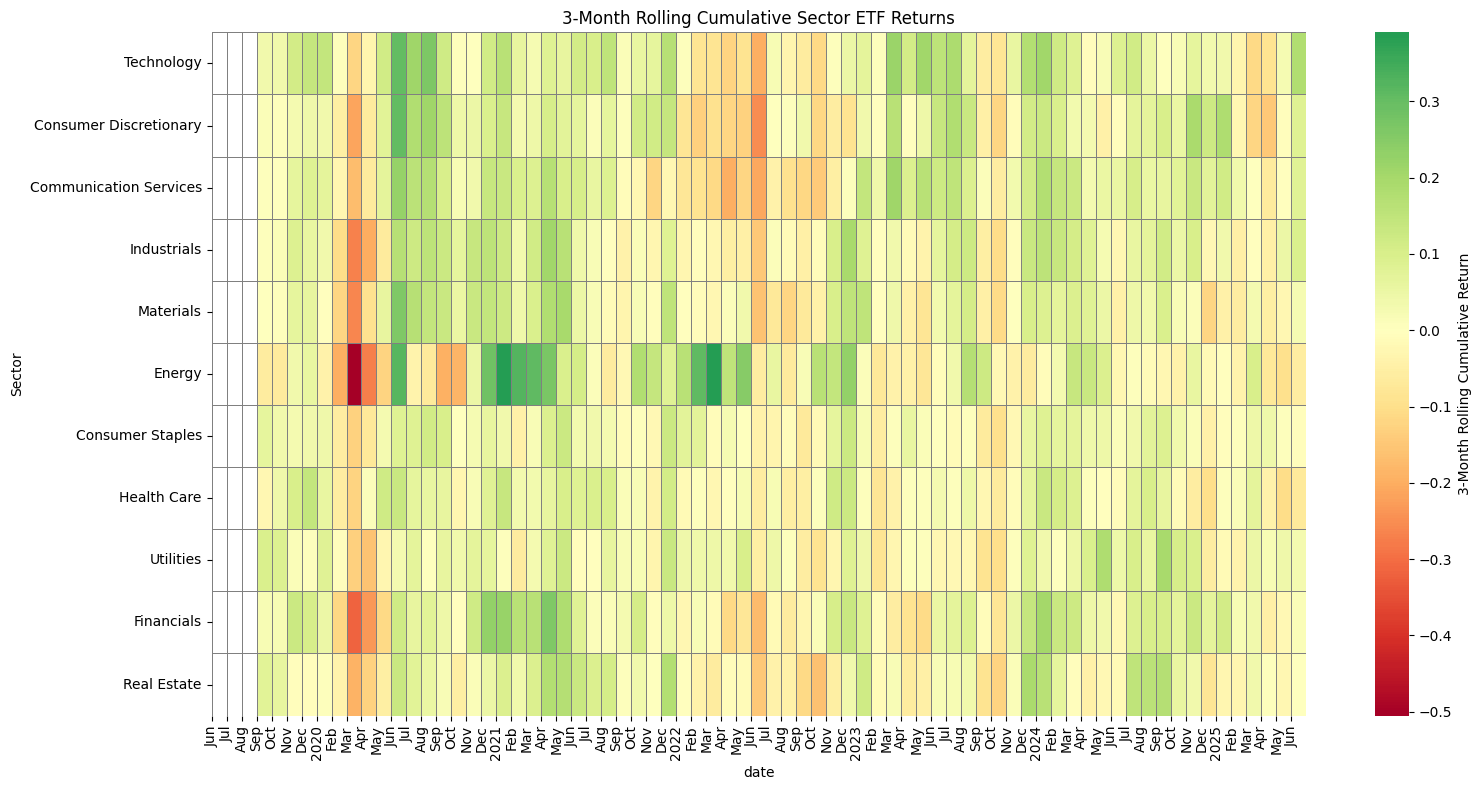

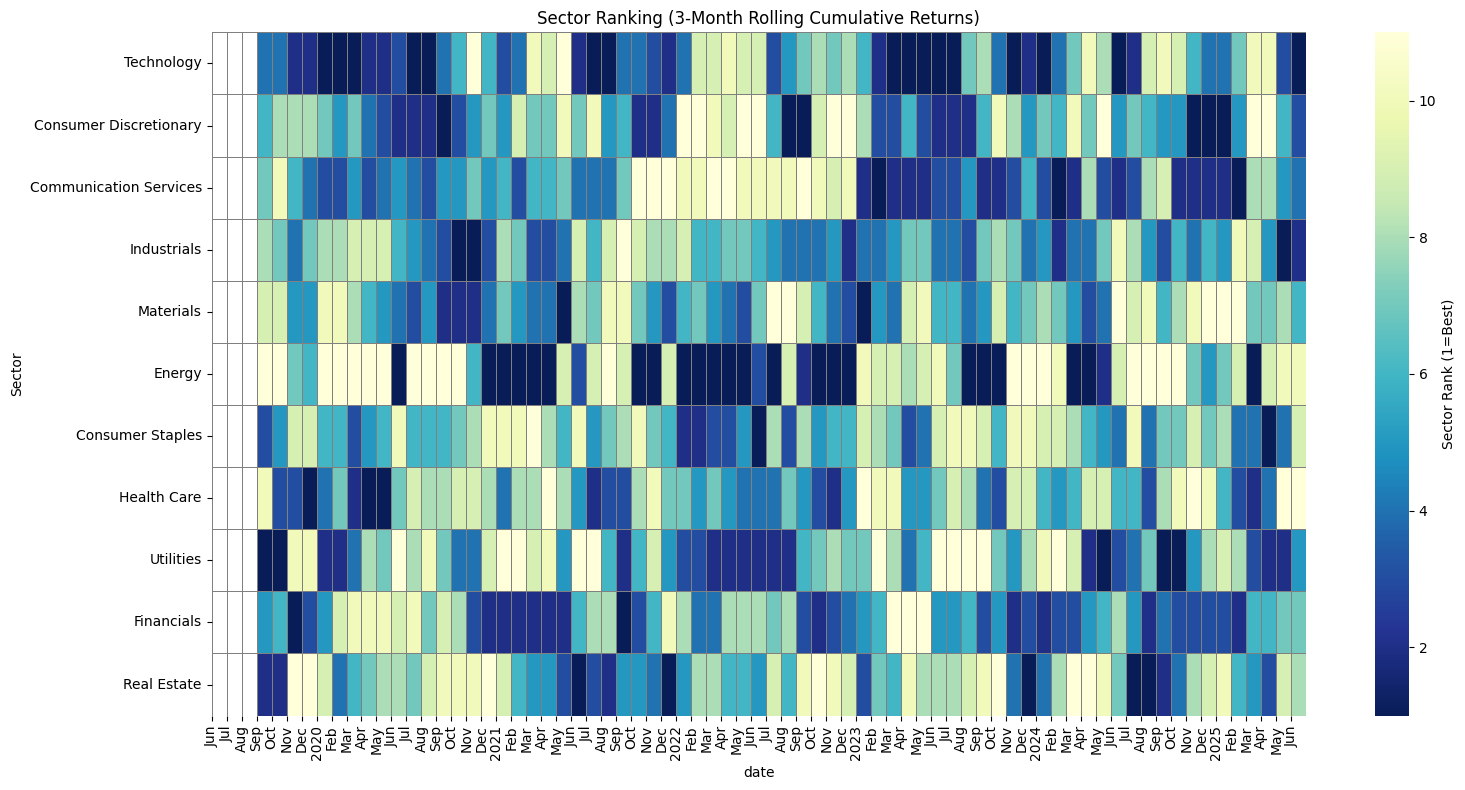

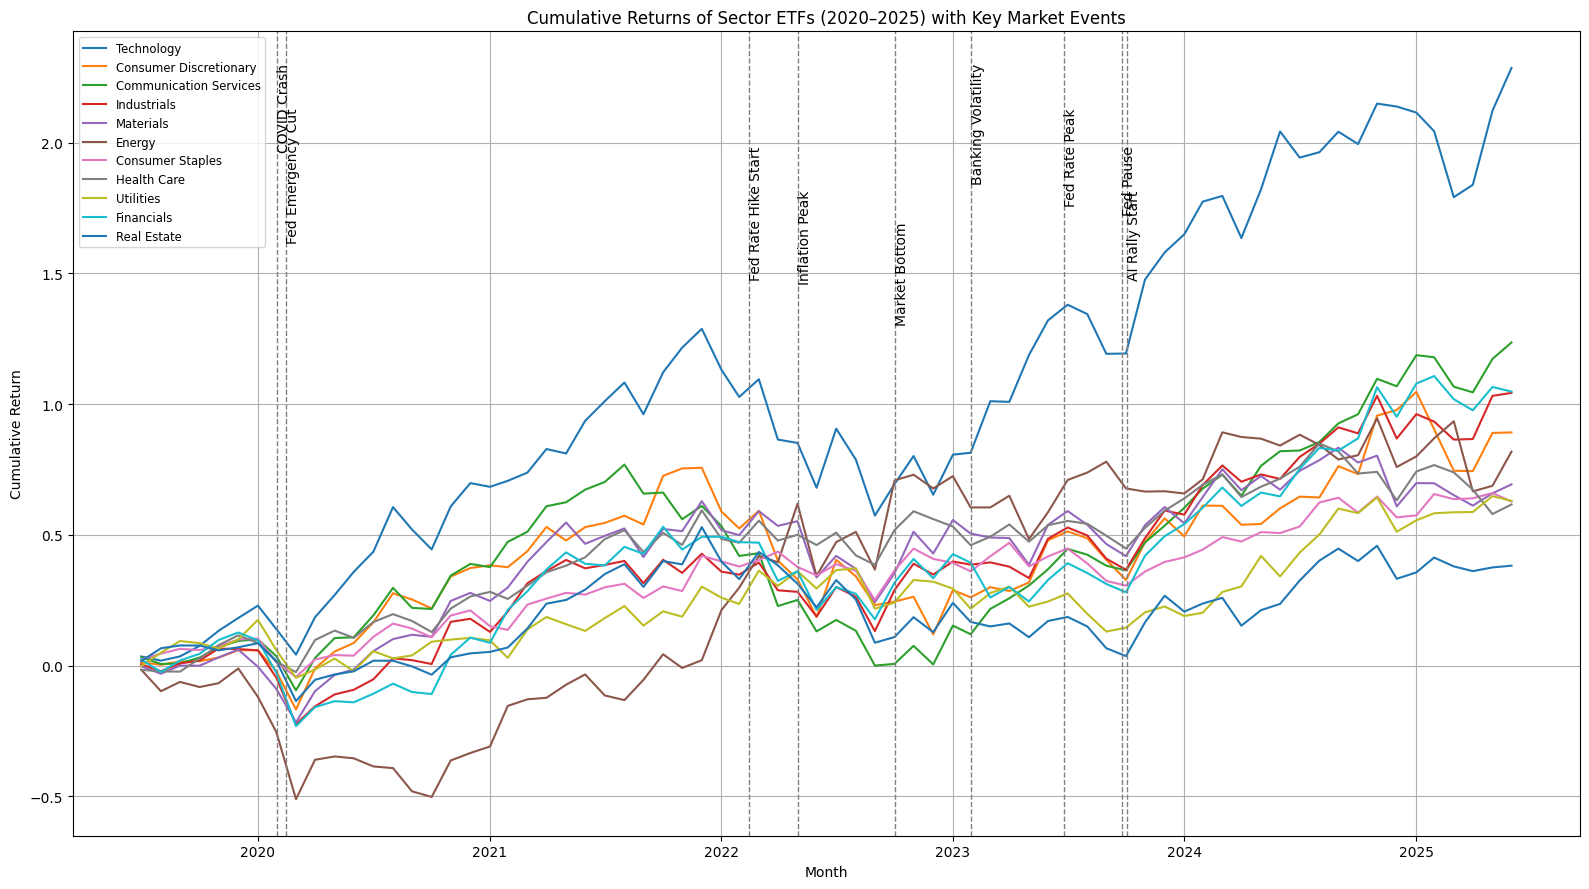

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import bigquery
import json
import os

# === Step 1: Define ETF tickers in textbook rotation order ===
etf_tickers_ordered = {
    "XLK": "Technology",
    "XLY": "Consumer Discretionary",
    "XLC": "Communication Services",
    "XLI": "Industrials",
    "XLB": "Materials",
    "XLE": "Energy",
    "XLP": "Consumer Staples",
    "XLV": "Health Care",
    "XLU": "Utilities",
    "XLF": "Financials",
    "XLRE": "Real Estate"
}

client = bigquery.Client()

# Load config files
with open("stock_config.json") as f:
    stock_config = json.load(f)

with open("bq_config.json") as f:
    bq_config = json.load(f)

# Set credentials and extract BigQuery info
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = bq_config["key"]
project_id = bq_config["project_id"]
dataset_id = bq_config["dataset_id"]
table_id = bq_config["table_id_fact_security"]

# === Step 2: Load data from BigQuery ===
query = f"SELECT * FROM `{project_id}.{dataset_id}.{table_id}`"
df = bigquery.Client().query(query).to_dataframe()
df["date"] = pd.to_datetime(df["date"])

# === Step 3: Pivot data into close prices ===
close_prices = df.pivot(index="date", columns="ticker_symbol", values="close_price")
close_prices = close_prices[list(etf_tickers_ordered.keys())]
close_prices = close_prices.sort_index()

# === Step 4: Compute monthly returns and rolling cumulative returns ===
monthly_prices = close_prices.resample("M").last()
monthly_returns = monthly_prices.pct_change()
monthly_returns.rename(columns=etf_tickers_ordered, inplace=True)

rolling_cum = (1 + monthly_returns).rolling(window=3).apply(lambda x: x.prod()) - 1
rolling_cum = rolling_cum[list(etf_tickers_ordered.values())]

# === Step 5: Format x-axis labels ===
dates = rolling_cum.index
x_labels = [str(dt.year) if dt.month == 1 else dt.strftime('%b') for dt in dates]

# === Plot 1: 3-Month Rolling Return Heatmap ===
plt.figure(figsize=(16, 8))
ax1 = sns.heatmap(
    rolling_cum.T,
    cmap="RdYlGn",
    center=0,
    cbar_kws={'label': '3-Month Rolling Cumulative Return'},
    xticklabels=False,
    linewidths=0.5,
    linecolor='gray'
)
ax1.set_xticks(range(len(dates)))
ax1.set_xticklabels(x_labels, rotation=90, ha='center')
plt.title("3-Month Rolling Cumulative Sector ETF Returns")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

# === Plot 2: Rankings Heatmap ===
rankings = rolling_cum.rank(axis=1, ascending=False)
plt.figure(figsize=(16, 8))
ax2 = sns.heatmap(
    rankings.T,
    cmap="YlGnBu_r",
    cbar_kws={'label': 'Sector Rank (1=Best)'},
    xticklabels=False,
    linewidths=0.5,
    linecolor='gray'
)
ax2.set_xticks(range(len(dates)))
ax2.set_xticklabels(x_labels, rotation=90, ha='center')
plt.title("Sector Ranking (3-Month Rolling Cumulative Returns)")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

# === Plot 3: Cumulative Return Line Chart with Annotations ===
cumulative_returns = (1 + monthly_returns).cumprod() - 1
plt.figure(figsize=(16, 9))
for sector in etf_tickers_ordered.values():
    plt.plot(cumulative_returns.index, cumulative_returns[sector], label=sector)

# Annotations
events = {
    "COVID Crash": "2020-03-01",
    "Fed Emergency Cut": "2020-03-15",
    "Fed Rate Hike Start": "2022-03-16",
    "Inflation Peak": "2022-06-01",
    "Market Bottom": "2022-10-31",
    "Banking Volatility": "2023-03-01",
    "Fed Rate Peak": "2023-07-26",
    "Fed Pause": "2023-10-25",
    "AI Rally Start": "2023-11-01"
}

ymin, ymax = plt.ylim()
offset_levels = [0.95, 0.88, 0.82, 0.75, 0.70]
used_dates = set()
for i, (label, date_str) in enumerate(events.items()):
    date = pd.to_datetime(date_str)
    while date in used_dates:
        date += pd.Timedelta(days=1)
    used_dates.add(date)
    plt.axvline(x=date, color='gray', linestyle='--', lw=1)
    ypos = ymax * offset_levels[i % len(offset_levels)]
    plt.text(date, ypos, label, rotation=90, verticalalignment='top', fontsize=10, color='black')

# Clean x-axis: only show January each year as '2020', '2021', etc.
year_starts = cumulative_returns.index[cumulative_returns.index.month == 1]
plt.xticks(
    ticks=year_starts,
    labels=[dt.strftime('%Y') for dt in year_starts],
    rotation=0
)


plt.title("Cumulative Returns of Sector ETFs (2020–2025) with Key Market Events")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.legend(loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()
